# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

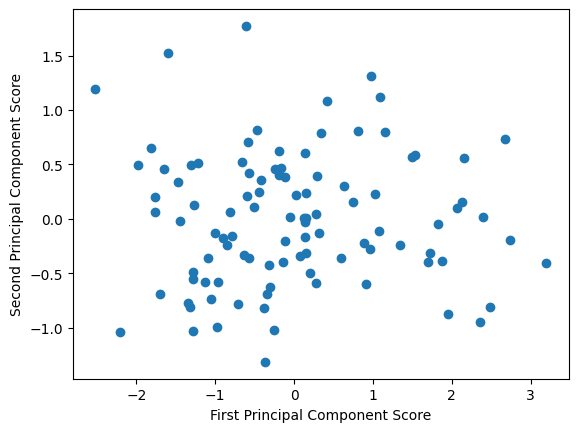

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The three outliers in the upper left corner of the graph have very low first principal component scores and high second principal component scores. This means that their data pattern is different from the rest. This means that they probably have low series_3 values which contributes to PC1. It also means that they have high values in series_1 and series_2 which contributes positively to PC2. So their combination of high ser1/ser2 and low ser3 sets them apart. It's harder to say something about series_1 and series_2 because series_1 and series_2 were created to be nearly linearly dependent. PCA treats them almost as a single variable and their similarity makes it hard to separate their individual contributions. Overall, the PCA scatter plot shows the main variation patterns in the dataset using two axes and capturing almost 99% of the variance. The advantage of the graph is that it compresses complex data into two dimensions while keeping most of the variance and highlights unusual points. The disadvantage is that the axes are abstract combinations of variables which makes it harder to interpret without examining the component weights and it hides the direct relationships like correlation between features.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

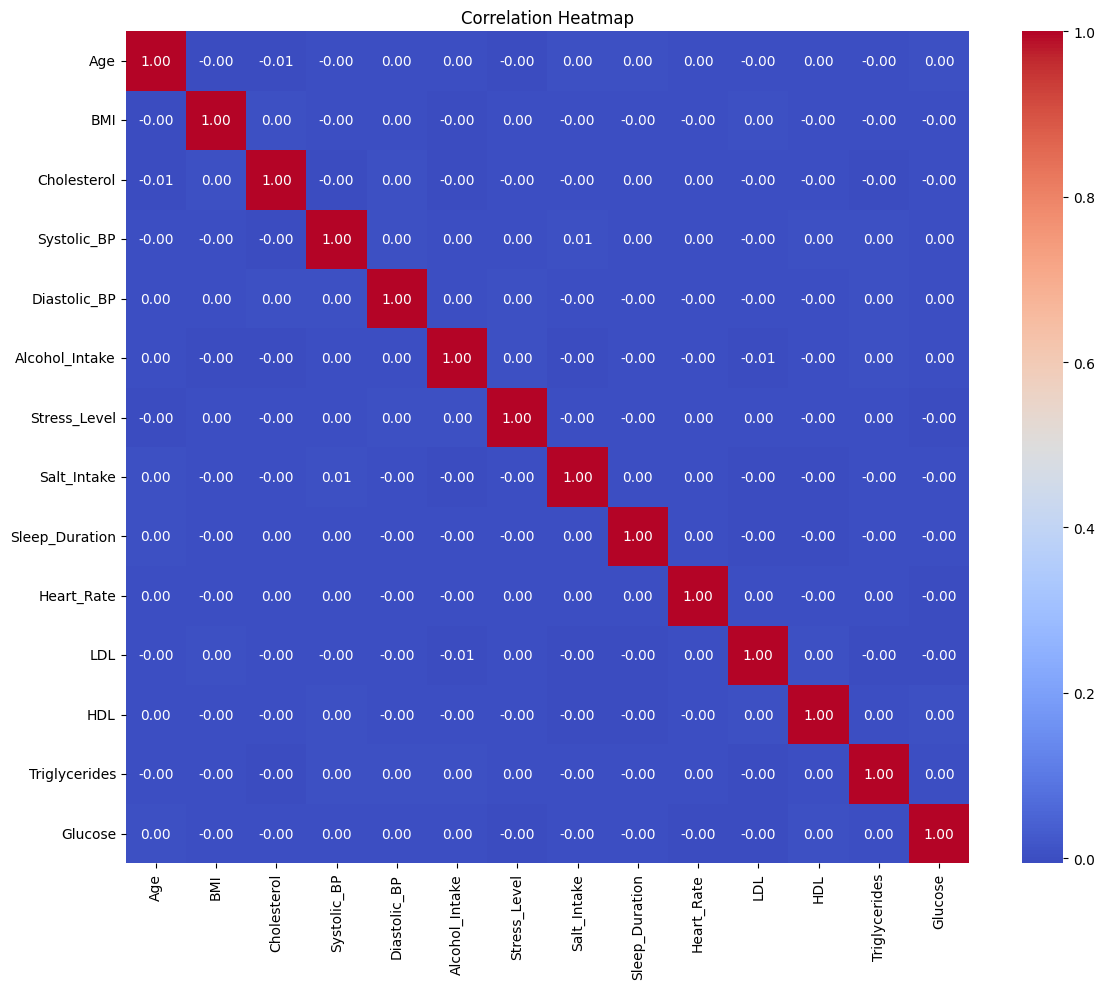

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("hypertension_dataset.csv")

numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

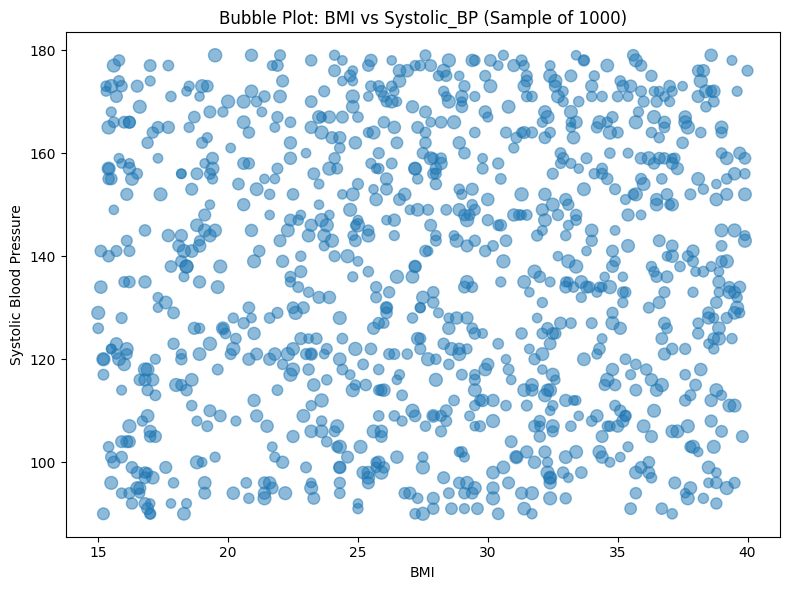

In [13]:
sample_df = df.sample(n=1000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_df['BMI'], sample_df['Systolic_BP'], 
            s=sample_df['Cholesterol'] * 0.3, alpha=0.5)
plt.xlabel("BMI")
plt.ylabel("Systolic Blood Pressure")
plt.title("Bubble Plot: BMI vs Systolic_BP (Sample of 1000)")
plt.tight_layout()
plt.show()


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Print explained variance
print("Explained Variance Ratios:", pca.explained_variance_ratio_)


Explained Variance Ratios: [0.07261993 0.0721946  0.07216913 0.07177506 0.07171853 0.07152091
 0.07142671 0.07132468 0.07122636 0.07100463 0.07099432 0.07091839
 0.07072484 0.0703819 ]


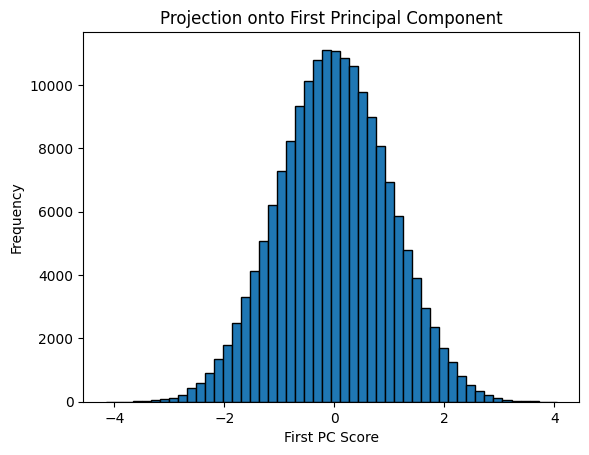

In [15]:
# Project data onto first PC
first_pc_projection = X_pca[:, 0]

# Optional: plot histogram of projection
plt.hist(first_pc_projection, bins=50, edgecolor='k')
plt.title("Projection onto First Principal Component")
plt.xlabel("First PC Score")
plt.ylabel("Frequency")
plt.show()

Conclusions:

The data looks good overall and makes sense for what we’re trying to study. Everything seems clean, and there’s a wide range of health-related features that could be useful for analysis. I think this dataset is definitely usable for predicting or analyzing hypertension risk.

There are a few outliers that show up in the visualizations, especially in the bubble plot. Some points had really high blood pressure or cholesterol values, so I’d probably look into those more before doing any modeling.

From the PCA results, it doesn’t look like the data can be reduced to just one or two principal components. The first component only explains about 7% of the variance, which means each feature adds its own information and can’t be easily compressed into fewer dimensions.

The correlation heatmap doesn’t show strong relationships between most variables, which was a little unexpected. But even though the correlations are low, I’d still consider using things like BMI, cholesterol, and blood pressure for regression since they logically seem related to hypertension, even if it’s not captured in the linear correlations.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

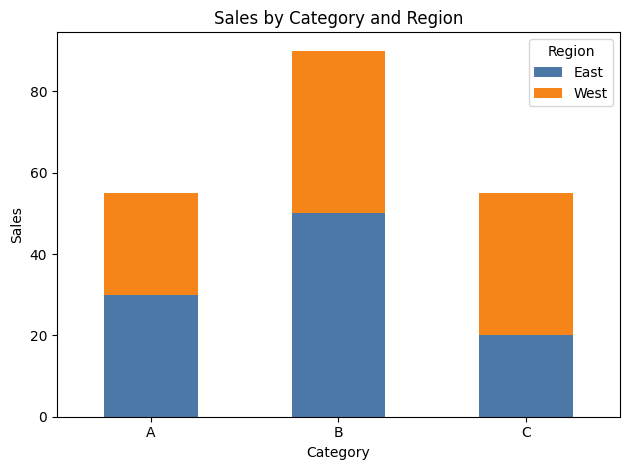

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Region': ['East', 'East', 'East', 'West', 'West', 'West'],
    'Category': ['A', 'B', 'C', 'A', 'B', 'C'],
    'Value': [30, 50, 20, 25, 40, 35]
}
df = pd.DataFrame(data)

pivot_df = df.pivot(index='Category', columns='Region', values='Value')

pivot_df.plot(kind='bar', stacked=True, color=['#4c78a8', '#f58518'])
plt.title('Sales by Category and Region')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.legend(title='Region')
plt.tight_layout()
plt.show()
